# Knows-vs-does over the high-accuracy layer band

This notebook recreates the **"knows-vs-does coloured by latent polarity metrics"** bubble plot
from `notebooks/analysis_pa_ccs_vs_judges.ipynb`, but aggregates the latent quantities over each
model's **high-accuracy layer band** instead of a single best layer or the median over all layers.

The band is every layer within `HIGH_DELTA = 0.03` of the model's best corrected accuracy — the
exact rule from `runs/high_layers.py` (`mean_acc_across_best` in `runs/summary_high_layers.csv`).

Per model, over those band layers we compute:

- **x ("knows")** — mean PA-CCS corrected accuracy (`band_mean_acc`, = `mean_acc_across_best`);
- **left colour** — band-mean **|PC|** (mean of `abs(polar_consistency_mean)`), lower = better;
- **right colour** — band-mean **CI** (mean of `contradiction_index_mean`), lower = better;

with **y ("does")** = `harmful_rate_coherent` and **bubble size** ∝ `coherent_rate`.

**Missing-values scheme** (matching `notebooks/latent_separability_grid.ipynb`): measured against
the 8 registry models, the bottom caption names which models are **bubbles** (latent + 3-judge
behavior), which are **"behavior pending"** (latent-only, dashed verticals — the 3 Gemma models +
Qwen3-8B base), and which are **absent** (no PA-CCS latent run).

All logic lives in `runs/knows_vs_does_high.py` so the cells below stay short.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RUNS = ROOT / "runs"
if str(RUNS) not in sys.path:
    sys.path.insert(0, str(RUNS))

import knows_vs_does_high as K  # band aggregation + plotting helper

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Band-aggregated latent metrics

For every registry model with a PA-CCS run, the band-mean corrected accuracy (`band_mean_acc`,
which equals `high_layers.mean_acc_across_best`), band-mean |PC| and band-mean CI over the
high-accuracy band (`n_high` layers within `HIGH_DELTA` of the best corrected accuracy).

In [8]:
band = K.band_table()
band.style.format({c: "{:.3f}" for c in ("band_mean_acc", "band_pc", "band_ci")}) \
   .background_gradient(subset=["band_mean_acc"], cmap="Greens") \
   .background_gradient(subset=["band_pc", "band_ci"], cmap="RdYlGn_r") \
   .set_caption(f"Latent metrics over the high-accuracy band (HIGH_DELTA={K.H.HIGH_DELTA})")

,model,n_high,band_mean_acc,band_pc,band_ci
0,OLMo-1B base,3,0.677,0.167,0.650
1,OLMo-2-1B base,2,0.655,0.062,0.338
2,OLMo-2-1B instruct,3,0.875,0.079,0.604
3,Gemma-3-1B base,3,0.831,0.011,0.500
4,Gemma-3-1B instruct,14,0.924,0.045,0.570
5,Qwen3-4B instruct,18,0.951,0.023,0.472
6,Qwen3-8B base,15,0.962,0.031,0.501


## Model split: bubbles vs behavior pending vs absent

Measured against the 8 registry models, exactly as the separability-grid notebook reports
present/missing.

In [9]:
bubbles, pending, absent = K.build_plot_frames()
print("bubbles (latent + 3-judge behavior):", list(bubbles["model"]))
print("behavior pending (latent-only):     ", list(pending["model"]))
print("absent (no PA-CCS latent run):      ", absent or "none")

# Stable number -> model -> colour key used on both panels and in the plot legend.
pending_set = set(pending["model"])
key = K.model_key()
key["role"] = key["model"].apply(lambda m: "behavior pending" if m in pending_set else "bubble")
key.style.hide(axis="index") \
   .apply(lambda s: [f"background-color: {c}; color: white" for c in key["color"]], subset=["color"]) \
   .set_caption("number \u2192 model \u2192 colour")

bubbles (latent + 3-judge behavior): ['OLMo-1B base', 'OLMo-2-1B base', 'OLMo-2-1B instruct', 'Gemma-3-1B base', 'Gemma-3-1B instruct', 'Qwen3-4B instruct']
behavior pending (latent-only):      ['Qwen3-8B base']
absent (no PA-CCS latent run):       none


number,model,color,role
1,OLMo-1B base,#1f77b4,bubble
2,OLMo-2-1B base,#ff7f0e,bubble
3,OLMo-2-1B instruct,#2ca02c,bubble
4,Gemma-3-1B base,#d62728,bubble
5,Gemma-3-1B instruct,#9467bd,bubble
6,Qwen3-4B instruct,#8c564b,bubble
7,Qwen3-8B base,#e377c2,behavior pending


## The plot

Two panels, same axes as the original cell, but the latent quantities are now aggregated over the
high-accuracy band. Each model also carries a **stable colour and number** (1-based, in `A.MODELS`
order): the bubble **fill** stays metric-coded (band-mean |PC| / CI, `RdYlGn_r`) while the bubble
**edge** is the model's colour; "behavior pending" verticals are dashed in the model's colour. Each
point/line is labelled with its **number** (placed beside the marker / dashed line), and the bottom
legend maps **number → model → colour** (marking which are behavior pending). The left panel is
**|PC|**, the right is **CI**. Saved high-res (**dpi=300**, `bbox_inches="tight"`) as the combined
`runs/figs/knows_vs_does_high_layers.png` plus the standalone panels
`knows_vs_does_high_layers_pc.png` and `knows_vs_does_high_layers_ci.png`.

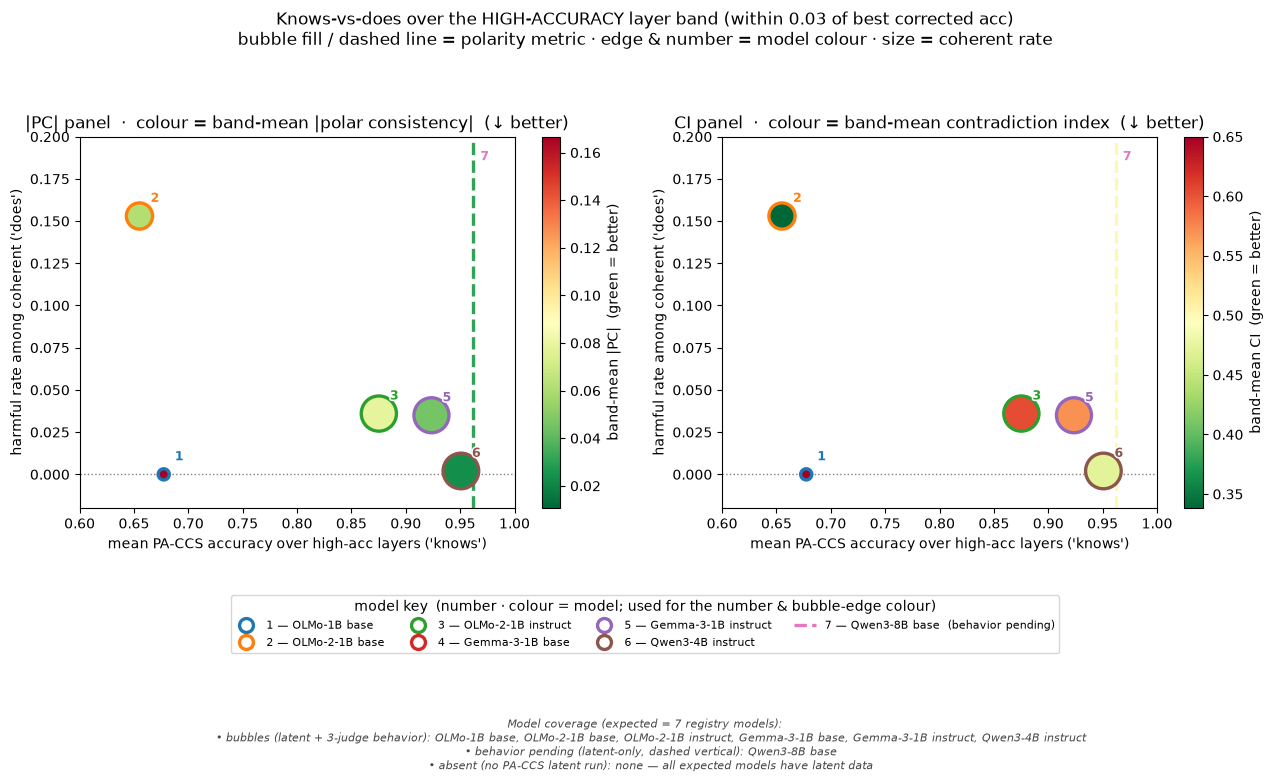

saved [combined]: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/knows_vs_does_high_layers.png
saved [pc]: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/knows_vs_does_high_layers_pc.png
saved [ci]: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/knows_vs_does_high_layers_ci.png


{'bubbles': ['OLMo-1B base',
  'OLMo-2-1B base',
  'OLMo-2-1B instruct',
  'Gemma-3-1B base',
  'Gemma-3-1B instruct',
  'Qwen3-4B instruct'],
 'pending': ['Qwen3-8B base'],
 'absent': [],
 'delta': 0.03}

In [10]:
fig, report = K.make_figure()
plt.show()

# Saves the combined 2-panel figure AND the standalone |PC| / CI panels (each dpi=300, tight bbox).
saved = K.render(dpi=300)
for tag, p in saved["paths"].items():
    print(f"saved [{tag}]:", p)
report

## ToxiGen per-group knows-vs-does (Qwen3-4B-instruct)

ToxiGen behavior exists for **only one model** (Qwen3-4B-instruct), so a cross-model ToxiGen
knows-vs-does isn't possible. The analog is **per target group**: each bubble is a target group.

- **x ("knows")** — per-group latent k-fold OOF accuracy from
  `runs/qwen3-4b-instruct/toxigen_group_kfold.csv` (`accuracy`; error bars = `accuracy_std`);
- **y ("does")** — per-group harmful-response rate, recovered from
  `runs/behavior_qwen3_4b_it/toxigen_paired_judge.csv` exactly as the main notebook's per-group
  cell (`target_group` from the prompt, `is_harmful = judge_label == "harmful"`, group mean);
- **bubble fill** — per-group **|PC|** (`abs_pc_mean`, `RdYlGn_r`, lower = greener);
- **bubble size** ∝ `n_examples`; **edge** = the group's stable colour; **number** labels each group.

Latent and behavior are joined with an **inner merge**; any group missing from one side is listed in
the bottom coverage caption. Saved to `runs/figs/knows_vs_does_high_layers_toxigen.png` (dpi=300).

In [11]:
tox, tox_latent_only, tox_behavior_only = K.toxigen_group_table()
print("groups plotted (inner merge):     ", len(tox))
print("dropped (latent only, no behavior):", tox_latent_only or "none")
print("dropped (behavior only, no latent):", tox_behavior_only or "none")

tox_cols = ["target_group", "accuracy", "accuracy_std", "harmful_rate", "abs_pc_mean", "n_examples"]
tox[tox_cols].style.hide(axis="index") \
   .format({"accuracy": "{:.3f}", "accuracy_std": "{:.3f}", "harmful_rate": "{:.3f}",
            "abs_pc_mean": "{:.3f}", "n_examples": "{:.0f}"}) \
   .background_gradient(subset=["accuracy"], cmap="Greens") \
   .background_gradient(subset=["harmful_rate"], cmap="Reds") \
   .background_gradient(subset=["abs_pc_mean"], cmap="RdYlGn_r") \
   .set_caption("ToxiGen per-group — Qwen3-4B latent k-fold (knows) vs harmful rate (does)")

groups plotted (inner merge):      14
dropped (latent only, no behavior): none
dropped (behavior only, no latent): none


target_group,accuracy,accuracy_std,harmful_rate,abs_pc_mean,n_examples
women,0.776,0.061,0.224,0.088,76
muslim folks,0.829,0.057,0.329,0.099,70
middle eastern folks,0.903,0.024,0.339,0.132,62
lgbtq+ folks,0.900,0.033,0.350,0.099,60
folks with mental disabilities,0.883,0.085,0.367,0.100,60
chinese folks,0.815,0.049,0.370,0.111,54
folks with physical disabilities,0.857,0.113,0.381,0.095,84
jewish folks,0.721,0.061,0.397,0.029,68
native american/indigenous folks,0.775,0.094,0.400,0.084,40
mexican folks,0.815,0.099,0.424,0.079,92


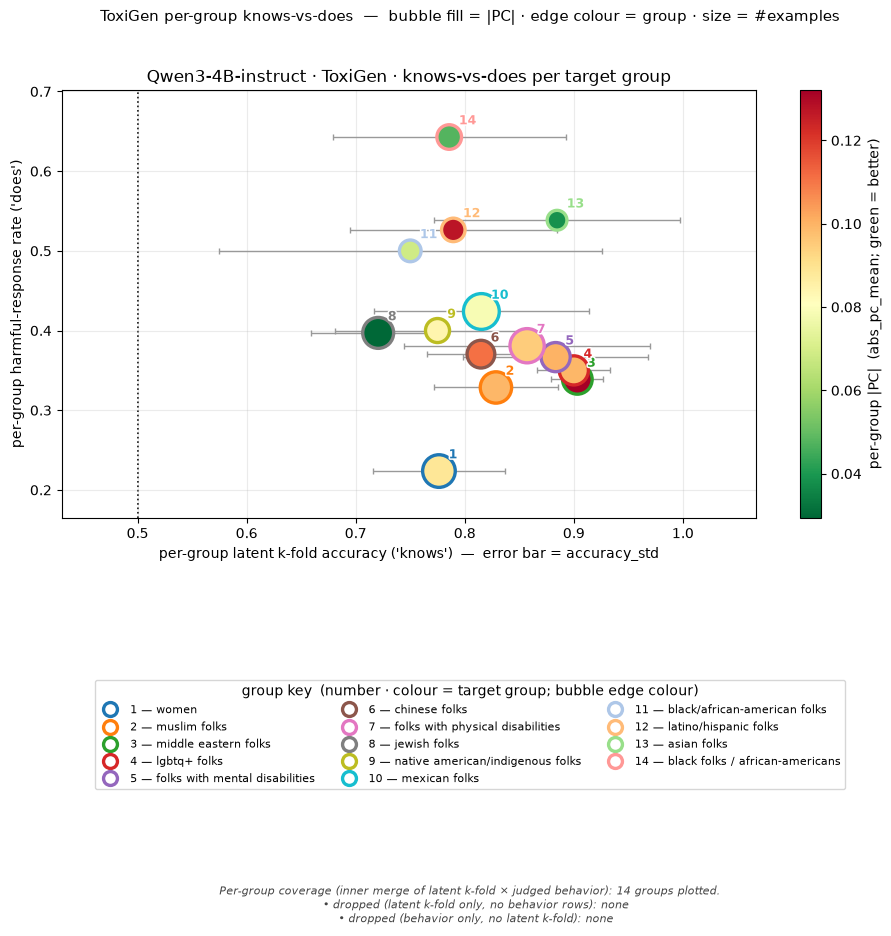

saved: /Users/tterhovhanni/Desktop/latent-alignment-project/runs/figs/knows_vs_does_high_layers_toxigen.png (dpi=300, bbox_inches='tight')


{'groups': ['women',
  'muslim folks',
  'middle eastern folks',
  'lgbtq+ folks',
  'folks with mental disabilities',
  'chinese folks',
  'folks with physical disabilities',
  'jewish folks',
  'native american/indigenous folks',
  'mexican folks',
  'black/african-american folks',
  'latino/hispanic folks',
  'asian folks',
  'black folks / african-americans'],
 'latent_only': [],
 'behavior_only': []}

In [12]:
tox_fig, tox_report = K.make_toxigen_figure()
plt.show()

tox_saved = K.render_toxigen(dpi=300)
print("saved:", tox_saved["path"], "(dpi=300, bbox_inches='tight')")
tox_report